In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import pickle
import glob

import scipy.stats as stats
from scipy.integrate import cumtrapz
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

import utils

#handle warnings
import warnings
warnings.filterwarnings("ignore")
np.random.seed(3)
np.set_printoptions(precision=5)

In [10]:
name = "CrTeNW_data"

root_dir = str(Path(os.getcwd()))
from_dir = root_dir + "/data/"
to_dir = root_dir + "/results/"

df_cleaned, X, Y, clean_feature_list, clean_result_col = utils.load_and_clean_data(name, feature_col_num=0,target="length")

Y_global_max = np.max(Y)



Loading CrTeNW_data dataset...
Features list: ['Te', 'Size', 'Ar', 'H_2', 'R_temp', 'G_temp', 'G_time', 'Q_Pre']
Feature size: 8
Dataset size: 94
Target column: Length
Sum of target values: 733.4399999999999
Mean of target values: 7.802553191489361
Y non-zero: 45 
Y zero: 49


## For histogram

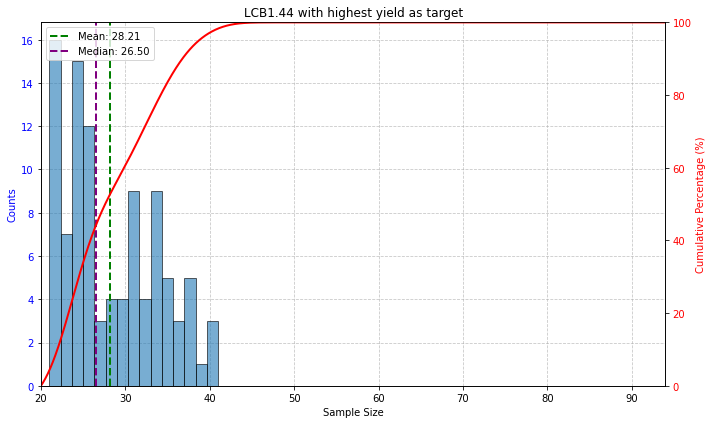

In [3]:
UF = "LCB1.44"
name = f"PAM_{UF}"

# Load data
filepath = os.path.join(from_dir, f"CrTeNW_data_{UF}.csv")

df = pd.read_csv(filepath)

data = df.iloc[:, 1]
labels = df.iloc[:, 0]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the histogram on the primary axis (counts)
counts, bins, patches = ax1.hist(data, bins=15, edgecolor='black', alpha=0.6)
ax1.set_xlabel('Sample Size')
ax1.set_ylabel('Counts', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Enable unified grid
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# Compute mean and median
mean_value = data.mean()
median_value = data.median()

# Mark mean and median with vertical lines on the primary axis
ax1.axvline(mean_value, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
ax1.axvline(median_value, color='purple', linestyle='--', linewidth=2, label=f'Median: {median_value:.2f}')

# Create the secondary axis for the smooth cumulative percentage curve
ax2 = ax1.twinx()

# Define a dense range of x values over the data's range
x = np.linspace(20, 94, 1000)

# Compute the KDE and cumulative percentage
kde = stats.gaussian_kde(data)
pdf = kde(x)
cdf = cumtrapz(pdf, x, initial=0)
cdf_percent = (cdf / cdf[-1]) * 100

# Plot the cumulative percentage on the secondary axis
ax2.plot(x, cdf_percent, color='red', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100)

# Set x-axis limits
ax1.set_xlim(20, 94)

# Combine legend entries from ax1 (which now includes mean and median markers)
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, loc='upper left')

plt.title(f'{UF} with highest yield as target')
plt.tight_layout()
plt.show()

Variance for EI: 164.30
Max Nc: 73


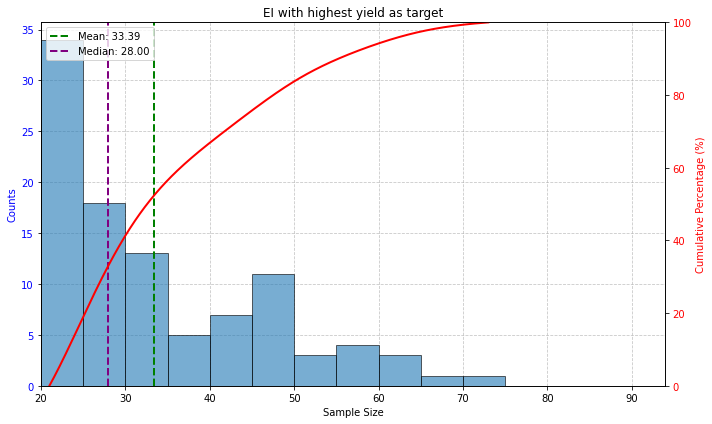

Variance for LCB: 54.84
Max Nc: 49


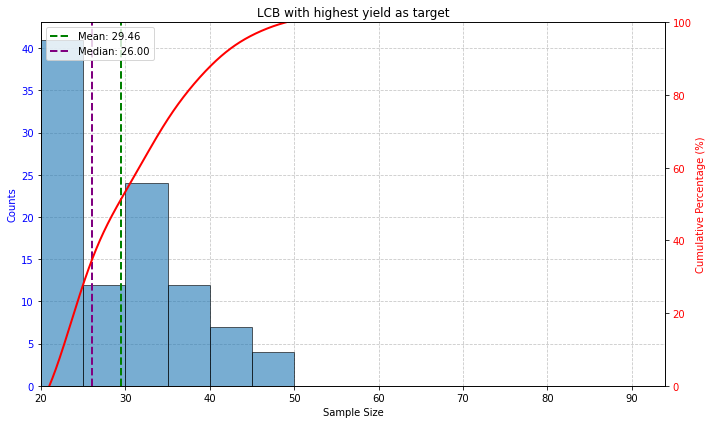

Variance for MOCU_mean: 43.91
Max Nc: 52


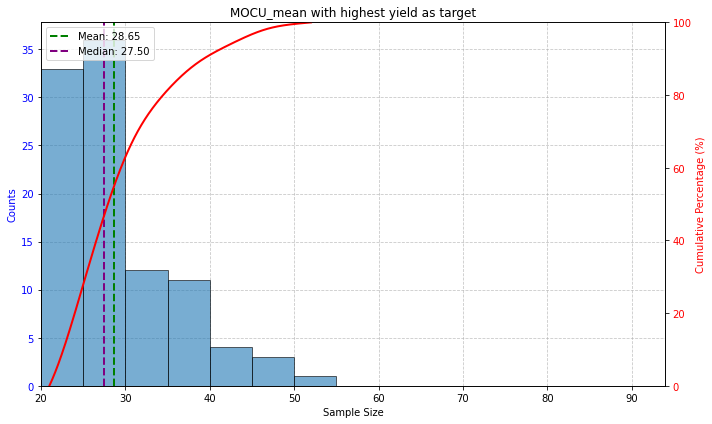

Variance for MOCU_std_dev: 544.59
Max Nc: 84


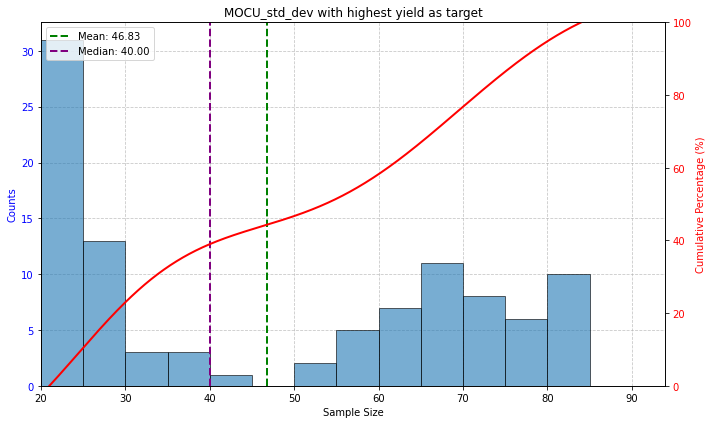

Variance for rank_score: 27.95
Max Nc: 44


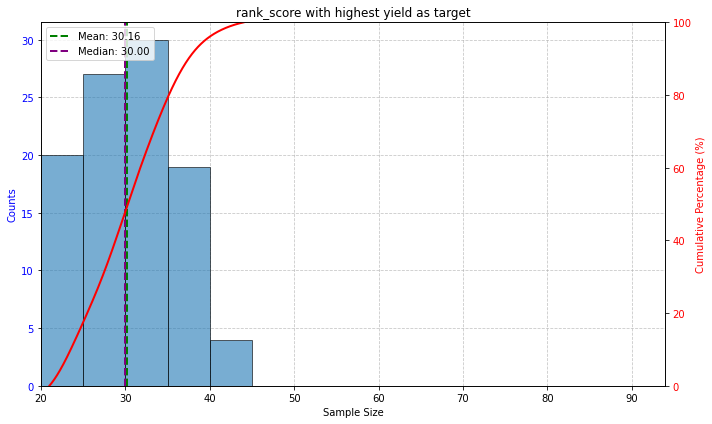

Variance for rank_score0.2: 36.31
Max Nc: 49


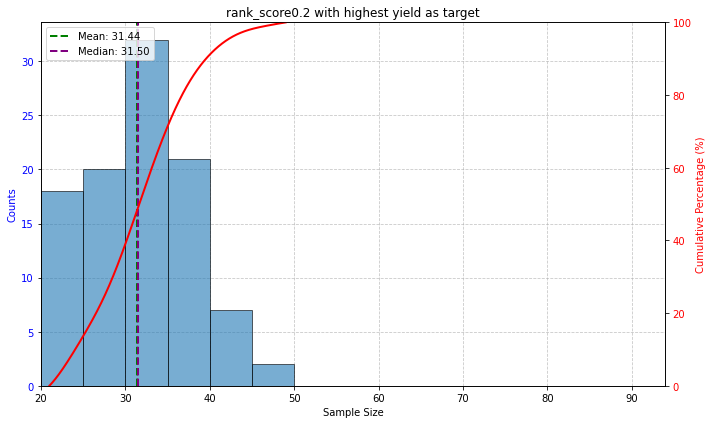

Variance for LCBrankdata: 75.26
Max Nc: 54


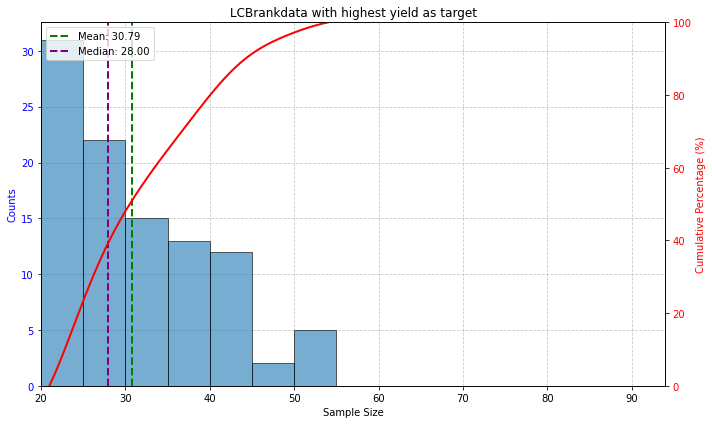

Variance for LCB1.64: 35.42
Max Nc: 50


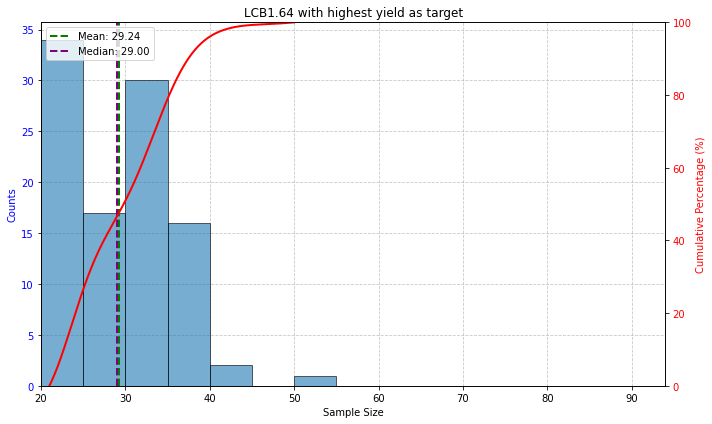

Variance for LCB1.44: 30.31
Max Nc: 41


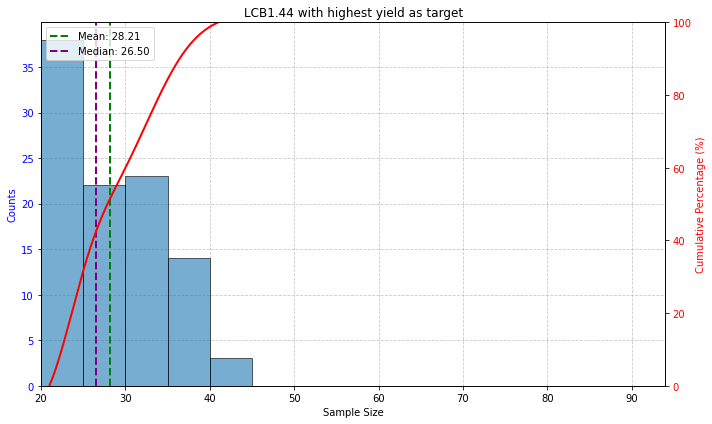

Variance for LCB1.282: 28.06
Max Nc: 45


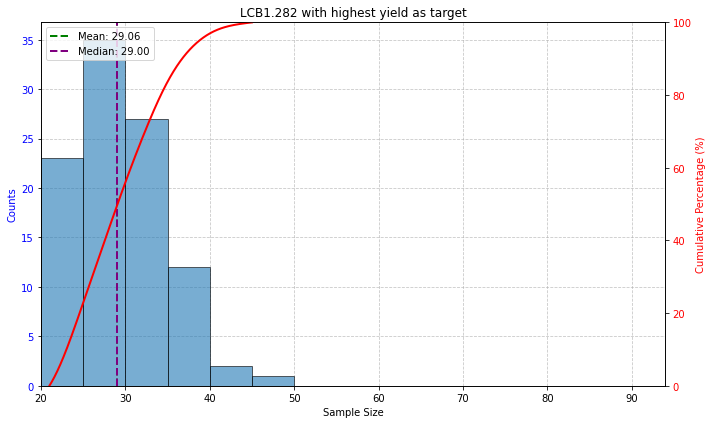

Variance for LCBrank1.282: 34.79
Max Nc: 45


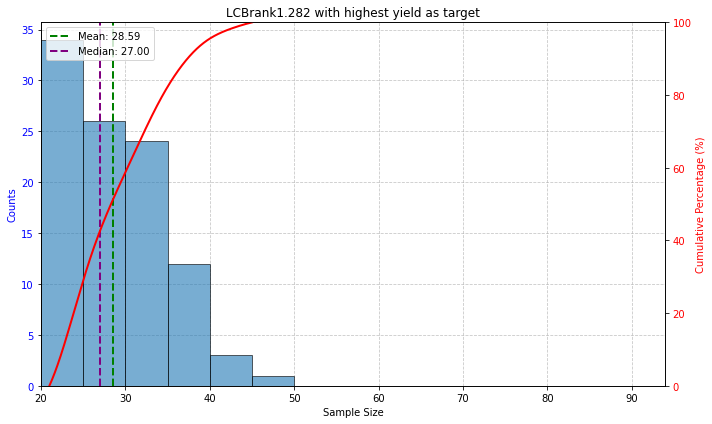

Variance for LCBrandom1.44: 49.24
Max Nc: 52


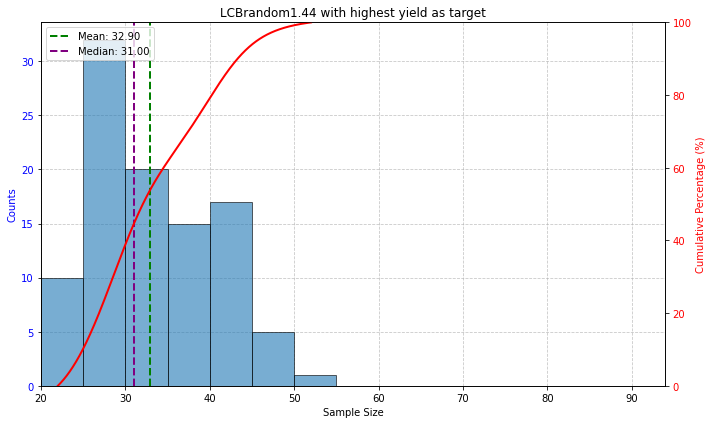

In [4]:
UF_array = ["EI", "LCB", "MOCU_mean", "MOCU_std_dev", "rank_score", "rank_score0.2","LCBrankdata","LCB1.64","LCB1.44", "LCB1.282","LCBrank1.282", "LCBrandom1.44"]
#UF_array = ["LCB1.44", "LCBrandom1.44","MOCU_mean","MOCU_meanrandom","rank_score","rank_scorerandom"]
to_save = 0

# Dictionary to store results for each UF
results = {}

for UF in UF_array:
    # Construct file name and path
    filename = f"CrTeNW_data_{UF}.csv"
    filepath = os.path.join(from_dir, filename)
    
    # Read the CSV file
    df = pd.read_csv(filepath)
    data = df.iloc[:, 1]
    labels = df.iloc[:, 0]
    
    # Store the data and labels
    results[UF] = {"data": data, "labels": labels}

    variance_value = data.var(ddof=1)  # Pandas computes unbiased sample variance by default :contentReference[oaicite:0]{index=0}
    results[UF]['variance'] = variance_value
    print(f"Variance for {UF}: {variance_value:.2f}")
    print("Max Nc:",max(data))

    # Create a new figure for each UF
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Define fixed bin width, e.g., 5 units
    bin_width = 5
    # Determine the range of your data, e.g., from 0 to 100
    bins = np.arange(0, 100 + bin_width, bin_width)

    # Plot histogram (as in your original code)
    counts, bins, patches = ax1.hist(data, bins=bins, edgecolor='black', alpha=0.6)
    ax1.set_xlabel('Sample Size')
    ax1.set_ylabel('Counts', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_axisbelow(True)
    
    # Compute and mark mean and median
    mean_value = data.mean()
    median_value = data.median()
    ax1.axvline(mean_value, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
    ax1.axvline(median_value, color='purple', linestyle='--', linewidth=2, label=f'Median: {median_value:.2f}')
    
    # Create secondary axis for the cumulative percentage curve
    ax2 = ax1.twinx()
    x = np.linspace(data.min(), data.max(), 1000)
    kde = stats.gaussian_kde(data.values)
    pdf = kde(x)
    cdf = cumtrapz(pdf, x, initial=0)
    cdf_percent = (cdf / cdf[-1]) * 100
    ax2.plot(x, cdf_percent, color='red', linewidth=2)
    ax2.set_ylabel('Cumulative Percentage (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 100)
    
    # Set x-axis limits based on data range (or use fixed limits if required)
    ax1.set_xlim(20, 94)
    
    # Combine legends and display plot
    lines, leg_labels = ax1.get_legend_handles_labels()
    ax1.legend(lines, leg_labels, loc='upper left')
    plt.title(f'{UF} with highest yield as target')
    plt.tight_layout()
    
    if to_save:
        plot_filename = f"{UF}_histogram.png"
        save_filepath = os.path.join(to_dir, plot_filename)
        plt.savefig(save_filepath, dpi=300, bbox_inches='tight')

    plt.show()

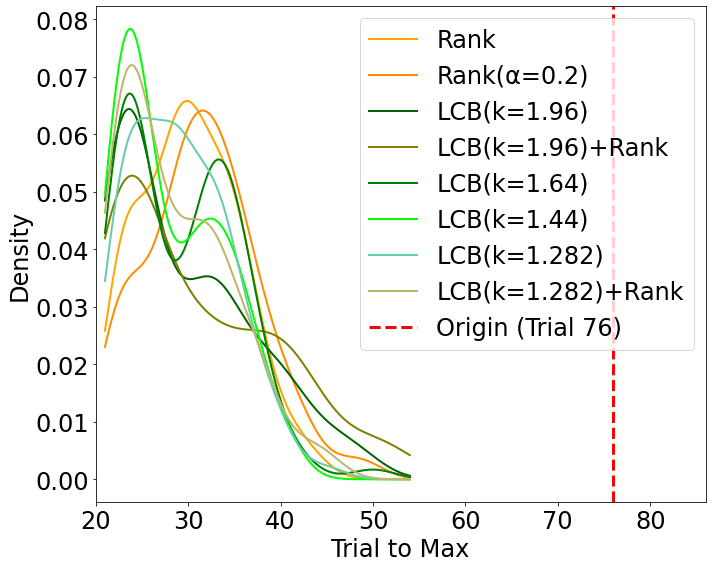

In [6]:
UF_array = ["rank_score", "rank_score0.2", "LCB", "LCBrankdata","LCB1.64","LCB1.44", "LCB1.282","LCBrank1.282"]
colors = ['orange', 'darkorange','darkgreen', 'olive','green','lime','mediumaquamarine','darkkhaki']

renaming = {"rank_score":"Rank",
            "rank_score0.2": "Rank(α=0.2)",
            "LCB":"LCB(k=1.96)",
            "LCBrankdata":"LCB(k=1.96)+Rank",
            "LCB1.64":"LCB(k=1.64)",
            "LCB1.44":"LCB(k=1.44)",
            "LCB1.282":"LCB(k=1.282)",
            "LCBrank1.282":"LCB(k=1.282)+Rank"}

color_mapping = dict(zip(UF_array, colors))

# Dictionary to store data for each UF
data_dict = {}

# Load data for each UF
for UF in UF_array:
    filename = f"CrTeNW_data_{UF}.csv"
    filepath = os.path.join(from_dir, filename)
    df = pd.read_csv(filepath)
    data = df.iloc[:, 1]
    data_dict[UF] = data

# Determine global min and max for consistent x-axis across datasets
global_min = min(data.min() for data in data_dict.values())
global_max = max(data.max() for data in data_dict.values())
x = np.linspace(global_min, global_max, 1000)

# Create figure and axis for combined plot
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=False)

# Plot histogram (normalized as density) and KDE for each dataset
for i, UF in enumerate(UF_array):
    data = data_dict[UF]
    
    # Plot histogram with density normalization for comparability
    '''ax.hist(data, bins=15, density=True, alpha=0.3, edgecolor='black',
            color=colors[i], label=f'{UF} Histogram')'''
    variance = data.var(ddof=1)

    # Compute and plot KDE curve
    kde = stats.gaussian_kde(data)
    pdf = kde(x)
    ax.plot(x, pdf, color=color_mapping[UF], linewidth=2, 
            label=f'{renaming[UF]}' #(Var={variance:.2f})'
            )

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)   # full reset


ax.axvline(x=76, color='red', linestyle='--', linewidth=3, label = 'Origin (Trial 76)')
ax.set_xlim(20, 86)
#ax.set_ylim(0,0.08)
ax.tick_params(axis="y", labelsize=24)
ax.tick_params(axis="x", labelsize=24)
ax.set_xlabel('Trial to Max', fontsize = 24)
ax.set_ylabel('Density', fontsize = 24)
ax.legend(loc=1,fontsize = 24)
#ax.grid(True, linestyle='--', alpha=0.7)
#plt.title( "Trials for Surrogates to Achieve Max Target", fontsize = 24)
plt.tight_layout()
plt.show()

In [5]:
UF_array = ["LCB1.44", "LCBrandom1.44","MOCU_mean","MOCU_meanrandom"]
colors = ['lime', 'palegreen','red', 'rosybrown']
color_mapping = dict(zip(UF_array, colors))
# Dictionary to store each folder's DataFrame
folder_dfs = {}

for UF in UF_array:
    name = f"PAM_{UF}"
    folder_path = os.path.join(from_dir, name)
    # Check if UF requires the 'rankkappa' pattern.
    if UF in {"LCBrankdata", "LCB1.64"}:
        pattern = os.path.join(folder_path, f"NW_regression_R9_LCB_rankkappa_run_2025_*")
    else:
        pattern = os.path.join(folder_path, f"NW_regression_R9_*_run_2025_*")
    files = glob.glob(pattern)
    
    if files:
        # Read and combine all files from the folder into a single DataFrame
        df = pd.concat([pd.read_csv(file, header=0) for file in files], ignore_index=True)
        folder_dfs[UF] = df
    else:
        print(f"No files found for folder: {name}")

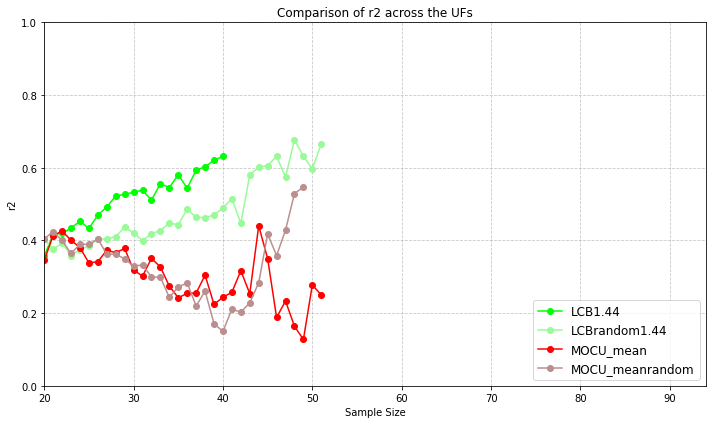

In [6]:
# Plotting the target variable "acq_value" from each DataFrame
UF_array = ["LCB1.44", "LCBrandom1.44","MOCU_mean","MOCU_meanrandom"]
targety1 = "r2"
plt.figure(figsize=(10, 6))
plt.xlim(20, 94)
plt.ylim(0,1)

def convert_y_true(val):
    # If the value is a string with brackets, remove them and convert to float.
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        return float(val.strip("[]"))
    return val

for i, UF in enumerate(UF_array):
    if UF in folder_dfs:
        df = folder_dfs[UF]
        # Group by sample_size to compute mean and std for the target
        stats = df.groupby("sample_size")[targety1].agg(["mean", "std"]).reset_index()
        plt.errorbar(stats["sample_size"], stats["mean"],
                     #yerr=stats["std"], 
                     fmt='-o', 
                     capsize=5,
                     color=color_mapping[UF], label=f'{UF}')
    else:
        print(f"Data for {UF} is missing.")

plt.xlabel("Sample Size")
plt.ylabel(f"{targety1}")
plt.title(f"Comparison of {targety1} across the UFs")
plt.legend(loc=4, fontsize = 12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

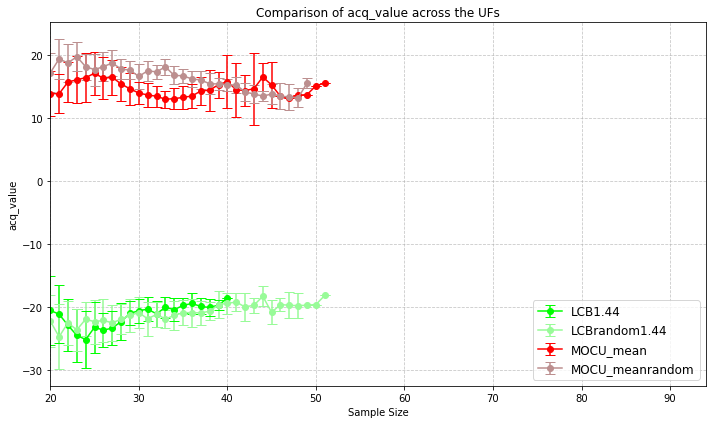

In [7]:
import os, pandas as pd, matplotlib.pyplot as plt

targety1 = "acq_value"

# --- 0) Build folder_dfs if it doesn't exist ---
try:
    folder_dfs  # noqa: F401
except NameError:
    if 'files' in globals() and 'UF_array' in globals():
        if len(files) < len(UF_array):
            raise RuntimeError("Not enough files to map to UF_array. Define 'folder_dfs' explicitly.")
        folder_dfs = {UF: pd.read_csv(f) for UF, f in zip(UF_array, files)}
    else:
        raise RuntimeError("Define 'folder_dfs' OR provide both 'files' and 'UF_array'.")

# --- 1) Ensure color_mapping exists ---
if 'color_mapping' not in globals():
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9'])
    color_mapping = {UF: colors[i % len(colors)] for i, UF in enumerate(UF_array)}

# --- 2) Plot (with your numeric coercion + named aggregation) ---
plt.figure(figsize=(10, 6))
plt.xlim(20, 94)

for UF in UF_array:
    if UF not in folder_dfs:
        print(f"Data for {UF} is missing.")
        continue

    df = folder_dfs[UF].copy()

    # robust numeric coercion
    df["sample_size"] = pd.to_numeric(df["sample_size"], errors="coerce")
    s = (df[targety1].astype(str).str.strip().str.strip("[]").str.replace(",", "", regex=False))
    df[targety1] = pd.to_numeric(s, errors="coerce")
    df = df.dropna(subset=["sample_size", targety1])

    # group & summarize (named aggregation)
    stats = (df.groupby("sample_size", as_index=False)
               .agg(mean=(targety1, "mean"),
                    std =(targety1, "std"))
               .sort_values("sample_size"))
    stats["std"] = stats["std"].fillna(0)

    plt.errorbar(stats["sample_size"], stats["mean"],
                 yerr=stats["std"], fmt='-o', capsize=5,
                 color=color_mapping.get(UF, None), label=f"{UF}")

plt.xlabel("Sample Size")
plt.ylabel(targety1)
plt.title(f"Comparison of {targety1} across the UFs")
plt.legend(loc=4, fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## Cummulative Regret

In [14]:
UF_array = ["LCB1.44", "LCBrandom1.44","MOCU_mean","MOCU_meanrandom","rank_score","rank_scorerandom"]
colors = ['lime', 'palegreen','red', 'rosybrown','orange','gold']
color_mapping = dict(zip(UF_array, colors))

# Dictionary to store each folder's DataFrame
folder_dfs = {}

for UF in UF_array:
    name = f"PAM_{UF}"
    folder_path = os.path.join(from_dir, name)
    
    # Check if UF requires the 'rankkappa' pattern.
    if UF in {"LCBrankdata", "LCB1.64"}:
        pattern = os.path.join(folder_path, f"NW_regression_R9_LCB_rankkappa_run_2025_*")
    else:
        pattern = os.path.join(folder_path, f"NW_regression_R9_*_run_2025_*")
        
    files = glob.glob(pattern)
    
    if files:
        # Read and combine all files from the folder into a single DataFrame
        df = pd.concat([pd.read_csv(file, header=0) for file in files], ignore_index=True)
        folder_dfs[UF] = df
    else:
        print(f"No files found for folder: {name}")

Y_global_max = Y_global_max

def convert_y_true(val):
    # If the value is a string with brackets, remove them and convert to float.
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        return float(val.strip("[]"))
    return val

for UF, df in folder_dfs.items():
    # Convert the y_true column to numeric values.
    df['y_true'] = df['y_true'].apply(convert_y_true)
    
    df['regret'] = Y_global_max - df['y_true']
    df['cumulative_regret'] = df['regret'].cumsum()
    # Uncomment the following lines to print the DataFrame header
    # print(f"Folder: PAM_{UF}")
    # print(df[['sample_size', 'y_true', 'regret', 'cumulative_regret']].head())

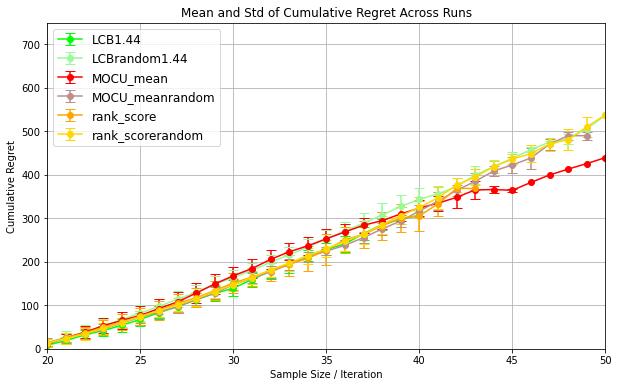

In [12]:
def convert_y_true(val):
    # If the value is a string with brackets, remove them and convert to float.
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        return float(val.strip("[]"))
    return val

plt.figure(figsize=(10, 6))

# Loop through each folder (UF value)
for UF in UF_array:
    folder_name = f"PAM_{UF}"
    folder_path = os.path.join(from_dir, folder_name)
    # Check if UF requires the 'rankkappa' pattern.
    if UF in {"LCBrankdata", "LCB1.64"}:
        pattern = os.path.join(folder_path, f"NW_regression_R9_LCB_rankkappa_run_2025_*")
    else:
        pattern = os.path.join(folder_path, f"NW_regression_R9_*_run_2025_*")

    files = glob.glob(pattern)
    
    if not files:
        print(f"No files found for folder: {folder_name}")
        continue

    # List to store per-run cumulative regret DataFrames
    dfs = []
    for file in files:
        df = pd.read_csv(file, header=0)
        df['y_true'] = df['y_true'].apply(convert_y_true)
        df['regret'] = Y_global_max - df['y_true']
        df['cumulative_regret'] = df['regret'].cumsum()
        dfs.append(df[['sample_size', 'cumulative_regret']])
    
    # Combine all runs for the current folder
    all_df = pd.concat(dfs, ignore_index=True)
    # Group by sample_size to compute mean and standard deviation
    agg_df = all_df.groupby('sample_size')['cumulative_regret'].agg(['mean', 'std']).reset_index()
    
    # Plot with error bars for the current folder
    plt.errorbar(agg_df['sample_size'], agg_df['mean'], yerr=agg_df['std'],
                 marker='o', capsize=5, linestyle='-', label=UF, color=color_mapping[UF])
plt.xlim(20,50)
plt.ylim(0,750)
plt.xlabel("Sample Size / Iteration")
plt.ylabel("Cumulative Regret")
plt.title("Mean and Std of Cumulative Regret Across Runs")
plt.grid(True)
plt.legend(fontsize = 12)
plt.show()

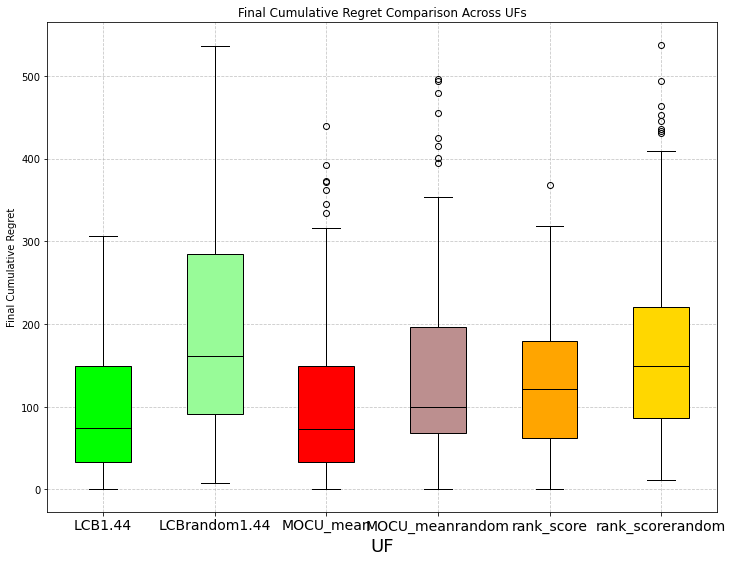

In [ ]:
def convert_y_true(val):
    # If the value is a string with brackets, remove them and convert to float.
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        return float(val.strip("[]"))
    return val

# Compute final cumulative regret for each run and compare across UFs using a boxplot
final_regrets = {}
for UF in UF_array:
    folder_name = f"PAM_{UF}"
    # Define folder_path here using folder_name
    folder_path = os.path.join(from_dir, folder_name)
    
    # Check if UF requires the 'rankkappa' pattern.
    if UF in {"LCBrankdata", "LCB1.64"}:
        pattern = os.path.join(folder_path, "NW_regression_R9_LCB_rankkappa_run_2025_*")
    else:
        pattern = os.path.join(folder_path, "NW_regression_R9_*_run_2025_*")
    
    files = glob.glob(pattern)
    
    if not files:
        print(f"No files found for folder: {folder_name}")
        continue
    
    final_values = []
    for file in files:
        df = pd.read_csv(file, header=0)
        df['y_true'] = df['y_true'].apply(convert_y_true)
        df['regret'] = Y_global_max - df['y_true']
        df['cumulative_regret'] = df['regret'].cumsum()
        final_values.append(df['cumulative_regret'].iloc[-1])
    final_regrets[UF] = final_values

# Plot boxplot comparing final cumulative regrets for each UF
plt.figure(figsize=(12, 9))
bp = plt.boxplot([final_regrets[UF] for UF in UF_array], labels=UF_array, patch_artist=True)

# Set custom colors for each box based on UF
for patch, UF in zip(bp['boxes'], UF_array):
    patch.set_facecolor(color_mapping[UF])
# Set the median line color to black
for median in bp['medians']:
    median.set_color('black')

plt.xlabel("UF", fontsize=18)
plt.ylabel("Final Cumulative Regret")
plt.title("Final Cumulative Regret Comparison Across UFs")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=14)
plt.show()